In [1]:
!pip install --quiet huggingface-hub

In [2]:
!git clone https://github.com/KihoPark/LLM_Categorical_Hierarchical_Representations.git

Cloning into 'LLM_Categorical_Hierarchical_Representations'...
remote: Enumerating objects: 84, done.
remote: Counting objects: 100% (84/84), done.
remote: Compressing objects: 100% (63/63), done.
remote: Total 84 (delta 25), reused 70 (delta 17), pack-reused 0 (from 0)
Receiving objects: 100% (84/84), 17.04 MiB | 9.26 MiB/s, done.
Resolving deltas: 100% (25/25), done.


In [3]:
%cd LLM_Categorical_Hierarchical_Representations

/content/LLM_Categorical_Hierarchical_Representations


In [4]:
!ls

01_eval_noun.ipynb	  06_subgraph.ipynb		    hierarchical
02_eval_verb.ipynb	  07_eval_gamma.ipynb		    README.md
03_eval_noun_llama.ipynb  data				    requirements.txt
04_intervention.ipynb	  get_wordnet_hypernym_gemma.ipynb
05_visualization.ipynb	  get_wordnet_hypernym_llama.ipynb


In [5]:
from huggingface_hub import login

login()

In [6]:
import torch
import numpy as numpy
import json
from transformers import AutoTokenizer
import networkx as nx
import random
import matplotlib.pyplot as plt
from tqdm import tqdm
import hierarchical as hrc

device = torch.device("cuda:0")
MODEL_NAME = "meta-llama/Meta-Llama-3-8B"
g, _, _ = hrc.get_g(MODEL_NAME, device)
vocab_dict, vocab_list = hrc.get_vocab(MODEL_NAME)

config.json:   0%|          | 0.00/654 [00:00<?, ?B/s]

model.safetensors.index.json:   0%|          | 0.00/23.9k [00:00<?, ?B/s]

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

model-00003-of-00004.safetensors:   0%|          | 0.00/4.92G [00:00<?, ?B/s]

model-00001-of-00004.safetensors:   0%|          | 0.00/4.98G [00:00<?, ?B/s]

model-00004-of-00004.safetensors:   0%|          | 0.00/1.17G [00:00<?, ?B/s]

model-00002-of-00004.safetensors:   0%|          | 0.00/5.00G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

OutOfMemoryError: CUDA out of memory. Tried to allocate 112.00 MiB. GPU 0 has a total capacity of 22.16 GiB of which 11.38 MiB is free. Process 2880 has 22.14 GiB memory in use. Of the allocated memory 21.46 GiB is allocated by PyTorch, and 489.23 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

In [ ]:
import inflect
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
vocab = tokenizer.get_vocab()
vocab_set = set(vocab.keys())

p = inflect.engine()

In [ ]:
print(f"Loaded tokenizer for {MODEL_NAME}")
print(f"Vocabulary size: {len(vocab_set)}")

Get the wordnet noun sets.
Make them into a weakly connected graph and dictionary.
Map them to the LM vocabulary.
Create a json with all the synsets.
Save the adjacency list of the graph.

## Visualizing Animals Hierarchy

In [ ]:
import torch
import numpy as np
import json
from transformers import AutoTokenizer
import networkx as nx
import matplotlib.pyplot as plt
import hierarchical as hrc
from mpl_toolkits.mplot3d import Axes3D
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

device = torch.device("cuda:0")
MODEL_NAME = "google/gemma-2b"
g, _, _ = hrc.get_g(MODEL_NAME, device)
vocab_dict, vocab_list = hrc.get_vocab(MODEL_NAME)

config.json:   0%|          | 0.00/627 [00:00<?, ?B/s]

model.safetensors.index.json:   0%|          | 0.00/13.5k [00:00<?, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

model-00002-of-00002.safetensors:   0%|          | 0.00/67.1M [00:00<?, ?B/s]

model-00001-of-00002.safetensors:   0%|          | 0.00/4.95G [00:00<?, ?B/s]

...

generation_config.json:   0%|          | 0.00/137 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/33.6k [00:00<?, ?B/s]

tokenizer.model:   0%|          | 0.00/4.24M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.5M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/636 [00:00<?, ?B/s]

In [7]:
with open("data/virtues.json", "r", encoding="utf-8") as f:
  virtue_data = json.load(f)

virtue_categories = list(virtue_data.keys())

virtues_token, virtues_ind, virtues_g = hrc.get_animal_category(virtue_data, virtue_categories, vocab_dict, g)

virtue_dirs = {k: hrc.estimate_cat_dir(v, g, vocab_dict) for k, v in virtues_token.items()}
virtue_dirs

NameError: name 'vocab_dict' is not defined

In [ ]:
all_virtues_tokens = [a for k, v in virtues_token.items() for a in v]
virtue_dirs.update({'virtue': hrc.estimate_cat_dir(all_virtues_tokens, g, vocab_dict)})
virtue_dirs

{'prudence': {'lda': tensor([ 0.1245, -0.4500, -0.1989,  ..., -0.0102,  0.4973,  0.0869],
         device='cuda:0'),
  'mean': tensor([ 0.0954, -0.3577, -0.1261,  ...,  0.0147,  0.3993,  0.0640],
         device='cuda:0')},
 'justice': {'lda': tensor([ 0.5188, -0.0361, -0.2464,  ...,  0.0696,  0.2517,  0.0074],
         device='cuda:0'),
  'mean': tensor([ 0.5488,  0.0971, -0.1078,  ...,  0.0517,  0.2367,  0.0985],
         device='cuda:0')},
 'fortitude': {'lda': tensor([-0.0372, -0.2520,  0.0953,  ...,  0.1726, -0.0123, -0.1150],
         device='cuda:0'),
  'mean': tensor([-0.0924, -0.3537,  0.1857,  ...,  0.1332,  0.0549,  0.1124],
         device='cuda:0')},
 'temperance': {'lda': tensor([ 1.0577,  0.2395, -0.2751,  ..., -0.3979,  0.7026,  0.0349],
         device='cuda:0'),
  'mean': tensor([ 1.2245,  0.3804, -0.2044,  ..., -0.3050,  0.7809,  0.1773],
         device='cuda:0')},
 'virtue': {'lda': tensor([ 0.3334, -0.1229, -0.2332,  ..., -0.0140,  0.3500, -0.0542],
         devic

In [ ]:
virtues_token.update({'virtue': all_virtues_tokens})

virtue_dir1=tensor([ 0.3334, -0.1229, -0.2332,  ..., -0.0140,  0.3500, -0.0542],
       device='cuda:0')
virtue_dir2=tensor([ 0.5188, -0.0361, -0.2464,  ...,  0.0696,  0.2517,  0.0074],
       device='cuda:0')


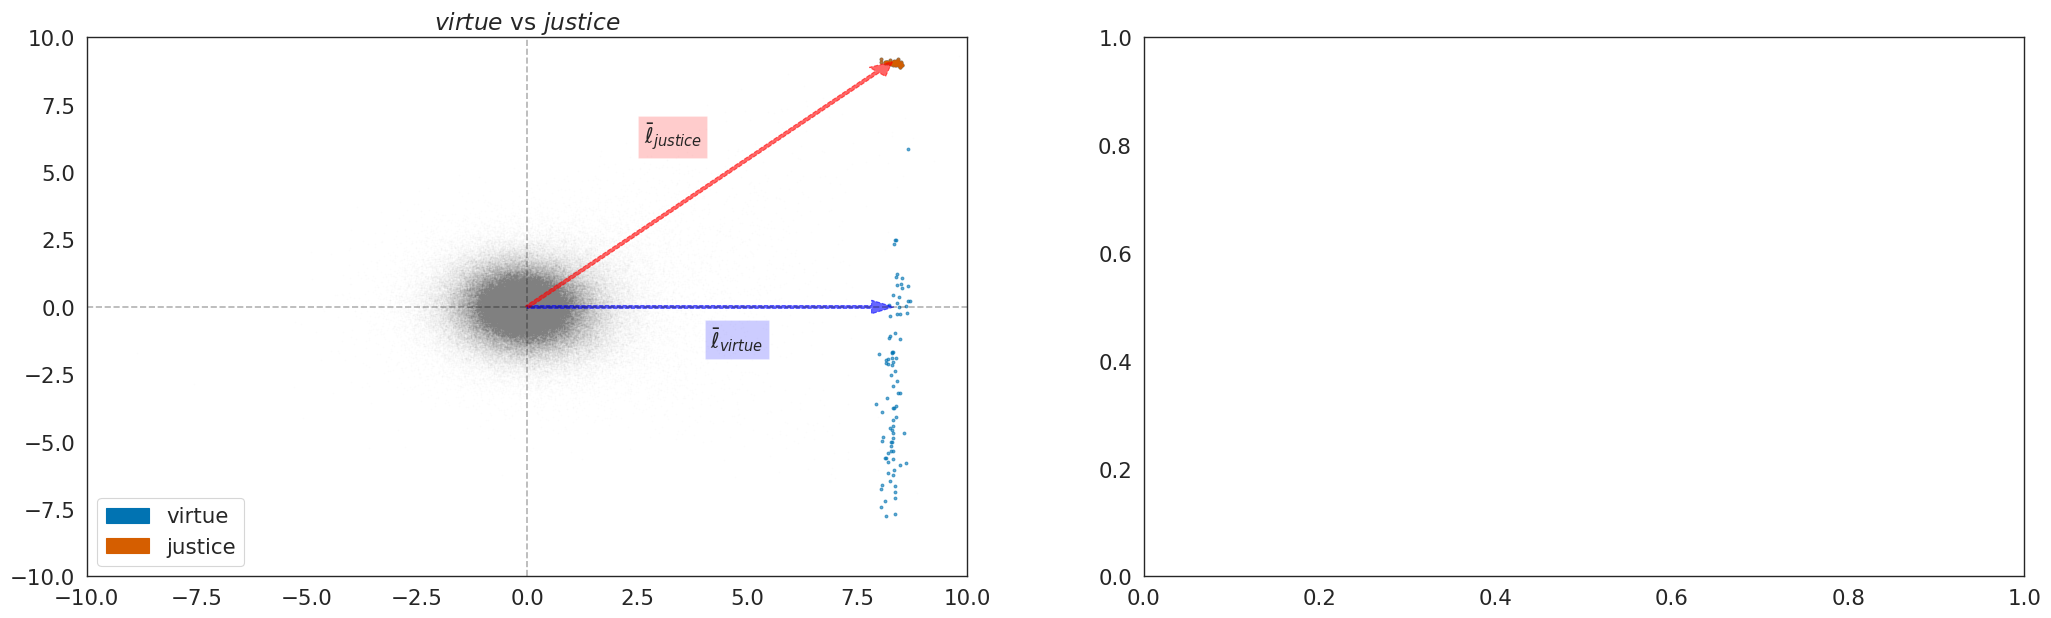

In [ ]:
fig, axs = plt.subplots(1, 2, figsize=(25, 7))

inds0 = {
    "virtue": hrc.category_to_indices(all_virtues_tokens, vocab_dict),
    "justice": hrc.category_to_indices(virtues_token['justice'], vocab_dict)
}
virtue_dir1 = virtue_dirs['virtue']['lda']
virtue_dir2 = virtue_dirs['justice']['lda']

print(f"{virtue_dir1=}")
print(f"{virtue_dir2=}")
hrc.proj_2d(
    virtue_dir1, virtue_dir2, g, vocab_list, axs[0],
    normalize=True,
    orthogonal=True,
    added_inds=inds0, k=200, fontsize=15,
    draw_arrows=True,
    arrow1_name=rf'$\bar{{\ell}}_{{virtue}}$',
    arrow2_name=rf'$\bar{{\ell}}_{{justice}}$',
    alpha = 0.03,
    s = 0.05,
    target_alpha=0.6,
    target_s=4,
    xlim=(-10, 10),
    ylim=(-10, 10),
    left_topk = False,
    bottom_topk = False,
    right_topk = False,
    top_topk = False,
    xlabel = "",
    ylabel = "",
    title = rf'$virtue$ vs $justice$'
)

In [ ]:
with open("data/vices.json", "r", encoding="utf-8") as f:
  vice_data = json.load(f)

vice_categories = list(vice_data.keys())

vices_token, vices_ind, vices_g = hrc.get_animal_category(vice_data, vice_categories, vocab_dict, g)

vice_dirs = {k: hrc.estimate_cat_dir(v, g, vocab_dict) for k, v in vices_token.items()}
vice_dirs

{'imprudence': {'lda': tensor([ 1.0491,  0.3283, -0.3482,  ...,  0.3893,  0.3926, -0.0272],
         device='cuda:0'),
  'mean': tensor([ 1.0381,  0.3512, -0.4012,  ...,  0.4295,  0.3656,  0.1358],
         device='cuda:0')},
 'injustice': {'lda': tensor([ 0.3666, -0.0731, -0.5003,  ..., -0.3405,  0.1973,  0.1292],
         device='cuda:0'),
  'mean': tensor([ 0.4464,  0.0041, -0.3083,  ..., -0.2974,  0.1877,  0.1383],
         device='cuda:0')},
 'cowardice': {'lda': tensor([ 0.5728,  0.2654, -0.2895,  ..., -0.1909, -0.4456, -0.2609],
         device='cuda:0'),
  'mean': tensor([ 0.7017,  0.3048, -0.2822,  ...,  0.1289, -0.4889, -0.1198],
         device='cuda:0')},
 'intemperance': {'lda': tensor([ 0.4107, -0.0792,  0.2650,  ..., -0.5636,  0.5655, -0.0646],
         device='cuda:0'),
  'mean': tensor([ 0.5059, -0.0855,  0.2984,  ..., -0.5568,  0.5777, -0.0929],
         device='cuda:0')}}

In [ ]:
all_vices_tokens = [a for k, v in vices_token.items() for a in v]
vice_dirs.update({'vice': hrc.estimate_cat_dir(all_vices_tokens, g, vocab_dict)})
vice_dirs

{'imprudence': {'lda': tensor([ 1.0491,  0.3283, -0.3482,  ...,  0.3893,  0.3926, -0.0272],
         device='cuda:0'),
  'mean': tensor([ 1.0381,  0.3512, -0.4012,  ...,  0.4295,  0.3656,  0.1358],
         device='cuda:0')},
 'injustice': {'lda': tensor([ 0.3666, -0.0731, -0.5003,  ..., -0.3405,  0.1973,  0.1292],
         device='cuda:0'),
  'mean': tensor([ 0.4464,  0.0041, -0.3083,  ..., -0.2974,  0.1877,  0.1383],
         device='cuda:0')},
 'cowardice': {'lda': tensor([ 0.5728,  0.2654, -0.2895,  ..., -0.1909, -0.4456, -0.2609],
         device='cuda:0'),
  'mean': tensor([ 0.7017,  0.3048, -0.2822,  ...,  0.1289, -0.4889, -0.1198],
         device='cuda:0')},
 'intemperance': {'lda': tensor([ 0.4107, -0.0792,  0.2650,  ..., -0.5636,  0.5655, -0.0646],
         device='cuda:0'),
  'mean': tensor([ 0.5059, -0.0855,  0.2984,  ..., -0.5568,  0.5777, -0.0929],
         device='cuda:0')},
 'vice': {'lda': tensor([ 0.3229,  0.0071, -0.0983,  ..., -0.4678,  0.1817, -0.0592],
         d

In [ ]:
vices_token.update({'vice': all_vices_tokens})

vice_dir1=tensor([ 0.3229,  0.0071, -0.0983,  ..., -0.4678,  0.1817, -0.0592],
       device='cuda:0')
vice_dir2=tensor([ 0.3666, -0.0731, -0.5003,  ..., -0.3405,  0.1973,  0.1292],
       device='cuda:0')


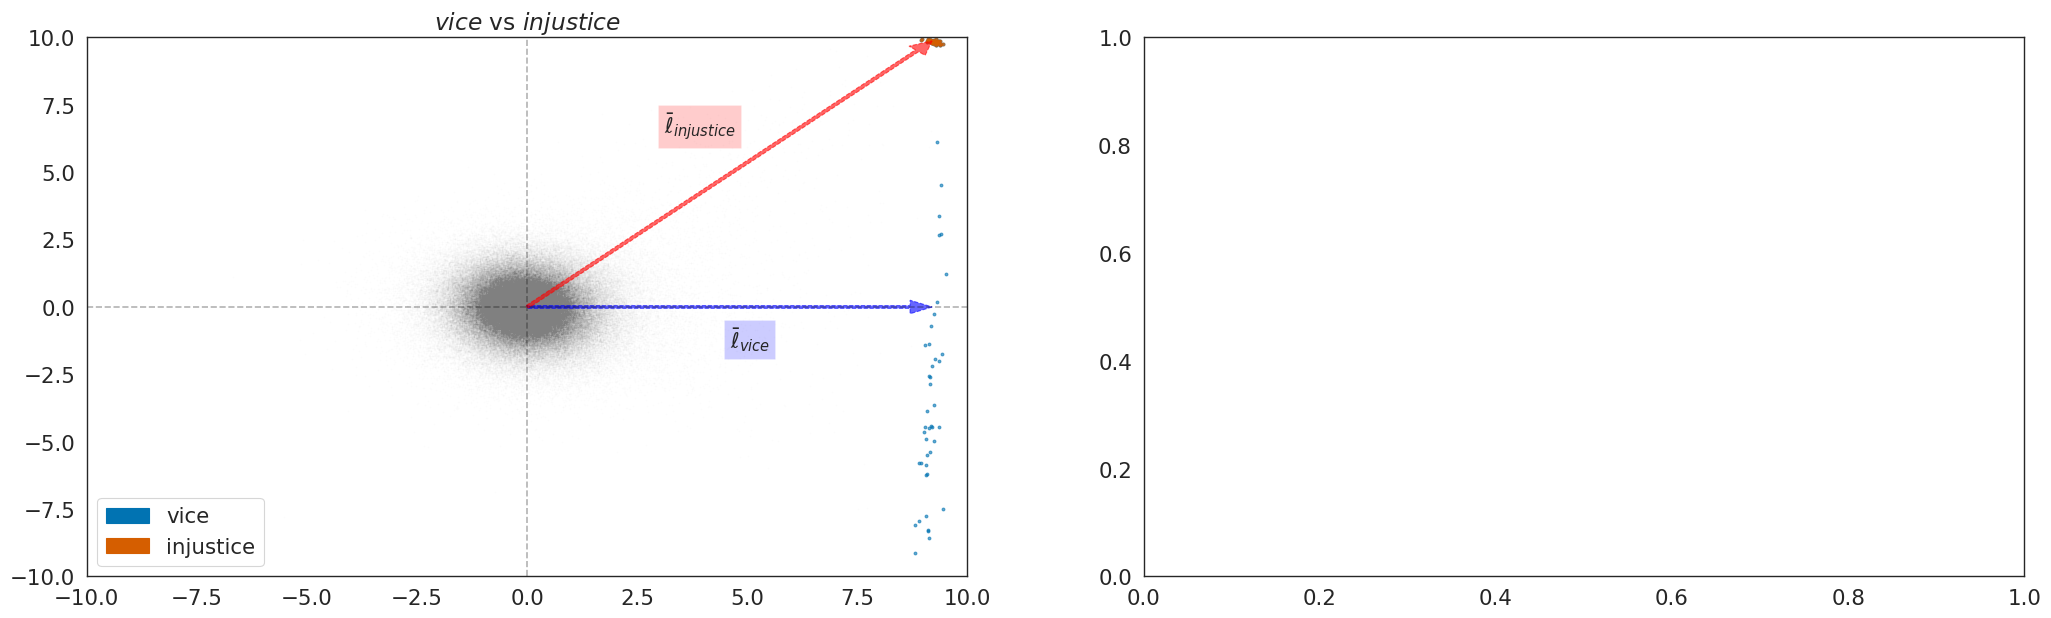

In [ ]:
fig, axs = plt.subplots(1, 2, figsize=(25, 7))

inds0 = {
    "vice": hrc.category_to_indices(all_vices_tokens, vocab_dict),
    "injustice": hrc.category_to_indices(vices_token['injustice'], vocab_dict)
}
vice_dir1 = vice_dirs['vice']['lda']
vice_dir2 = vice_dirs['injustice']['lda']

print(f"{vice_dir1=}")
print(f"{vice_dir2=}")
hrc.proj_2d(
    vice_dir1, vice_dir2, g, vocab_list, axs[0],
    normalize=True,
    orthogonal=True,
    added_inds=inds0, k=200, fontsize=15,
    draw_arrows=True,
    arrow1_name=rf'$\bar{{\ell}}_{{vice}}$',
    arrow2_name=rf'$\bar{{\ell}}_{{injustice}}$',
    alpha = 0.03,
    s = 0.05,
    target_alpha=0.6,
    target_s=4,
    xlim=(-10, 10),
    ylim=(-10, 10),
    left_topk = False,
    bottom_topk = False,
    right_topk = False,
    top_topk = False,
    xlabel = "",
    ylabel = "",
    title = rf'$vice$ vs $injustice$'
)

vice_dir1=tensor([ 0.3229,  0.0071, -0.0983,  ..., -0.4678,  0.1817, -0.0592],
       device='cuda:0')
virtue_dir1=tensor([ 0.3334, -0.1229, -0.2332,  ..., -0.0140,  0.3500, -0.0542],
       device='cuda:0')


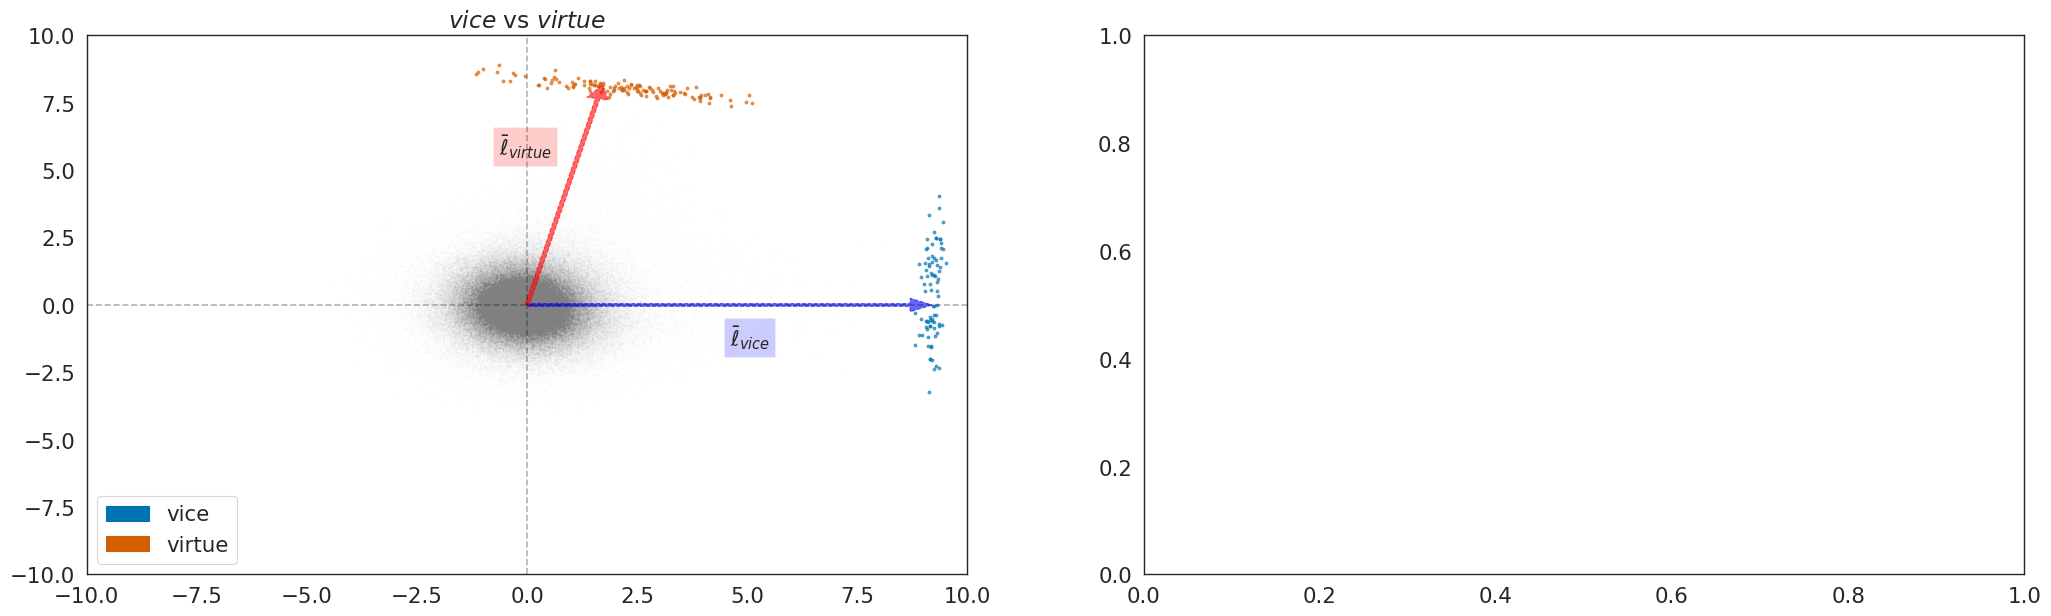

In [ ]:
fig, axs = plt.subplots(1, 2, figsize=(25, 7))

inds0 = {
    "vice": hrc.category_to_indices(all_vices_tokens, vocab_dict),
    "virtue": hrc.category_to_indices(all_virtues_tokens, vocab_dict)
}

print(f"{vice_dir1=}")
print(f"{virtue_dir1=}")
hrc.proj_2d(
    vice_dir1, virtue_dir1, g, vocab_list, axs[0],
    normalize=True,
    orthogonal=True,
    added_inds=inds0, k=200, fontsize=15,
    draw_arrows=True,
    arrow1_name=rf'$\bar{{\ell}}_{{vice}}$',
    arrow2_name=rf'$\bar{{\ell}}_{{virtue}}$',
    alpha = 0.03,
    s = 0.05,
    target_alpha=0.6,
    target_s=4,
    xlim=(-10, 10),
    ylim=(-10, 10),
    left_topk = False,
    bottom_topk = False,
    right_topk = False,
    top_topk = False,
    xlabel = "",
    ylabel = "",
    title = rf'$vice$ vs $virtue$'
)

In [ ]:
fig, axs = plt.subplots(1, 2, figsize=(25, 7))

inds0 = {
    "virtue": hrc.category_to_indices(all_virtues_tokens, vocab_dict),
    "justice": hrc.category_to_indices(virtues_token['justice'], vocab_dict)
}
dir1 = dirs['virtue']['lda']
dir2 = dirs['justice']['lda']

print(f"{dir1=}")
print(f"{dir2=}")
hrc.proj_2d(
    dir1, dir2, g, vocab_list, axs[0],
    normalize=True,
    orthogonal=True,
    added_inds=inds0, k=200, fontsize=15,
    draw_arrows=True,
    arrow1_name=rf'$\bar{{\ell}}_{{virtue}}$',
    arrow2_name=rf'$\bar{{\ell}}_{{justice}}$',
    alpha = 0.03,
    s = 0.05,
    target_alpha=0.6,
    target_s=4,
    xlim=(-10, 10),
    ylim=(-10, 10),
    left_topk = False,
    bottom_topk = False,
    right_topk = False,
    top_topk = False,
    xlabel = "",
    ylabel = "",
    title = rf'$virtue$ vs $justice$'
)

The main goal of `proj_2d` is to take two direction vectors from the model's embedding space and see which words in the vocabulary are most aligned with them.

1. Input Directions: The function takes two primary inputs. These are vectors that represent directions of interest. For example, dir1 could represent the concept of maleness and dir2 could represent royalty.

2. Direction Processing:

  - Normalization: The directions are scaled to be unit vectors. This is usually done to ensure that the lengths of the vectors don't affect the projection scores.
  - Orthogonaliztion: It can make dir2 perpendicular to dir1. This creates a standard 2D Cartesian coordinate system where the axes are independent, which can make the plot easier to interpret.

3. Vocabulary Projection: The function calculates the projection of every word in the vocabulary onto each of the two directions. This is done by taking the dot product of each word's embedding with the direction vectors. IN the code, this is efficiently calculated for the whole vocabulary at once:
```python
proj1 = unembed @ dir1
proj2 = unembed @ dir2
```
Here, `unembed` is the model's unembedding matrix (tying word embeddings to output logits), so this operation gives a score for every word in `vocab_list` along `dir1` and `dir2`.



In [ ]:
from transformers import AutoModelForCausalLM

MODEL_NAME = "meta-llama/Meta-Llama-3-8B"

model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    torch_dtype=torch.float16,
    device_map="auto",
    output_hidden_states=True
)
model.eval()

The following generation flags are not valid and may be ignored: ['output_hidden_states']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
The following generation flags are not valid and may be ignored: ['output_hidden_states']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

LlamaForCausalLM(
  (model): LlamaModel(
    (embed_tokens): Embedding(128256, 4096)
    (layers): ModuleList(
      (0-31): 32 x LlamaDecoderLayer(
        (self_attn): LlamaAttention(
          (q_proj): Linear(in_features=4096, out_features=4096, bias=False)
          (k_proj): Linear(in_features=4096, out_features=1024, bias=False)
          (v_proj): Linear(in_features=4096, out_features=1024, bias=False)
          (o_proj): Linear(in_features=4096, out_features=4096, bias=False)
        )
        (mlp): LlamaMLP(
          (gate_proj): Linear(in_features=4096, out_features=14336, bias=False)
          (up_proj): Linear(in_features=4096, out_features=14336, bias=False)
          (down_proj): Linear(in_features=14336, out_features=4096, bias=False)
          (act_fn): SiLU()
        )
        (input_layernorm): LlamaRMSNorm((4096,), eps=1e-05)
        (post_attention_layernorm): LlamaRMSNorm((4096,), eps=1e-05)
      )
    )
    (norm): LlamaRMSNorm((4096,), eps=1e-05)
    (rotary_

In [ ]:
@torch.no_grad()
def embed(text: str, layer: int = -1) -> torch.Tensor:
    """
    Return a d-dim embedding for `text` from the chosen layer of Llama-8B.
    layer = -1 ⇒ final layer, -2 ⇒ penultimate, etc.
    """
    ids = tokenizer(text, return_tensors="pt", add_special_tokens=True).to(model.device)
    out = model(**ids)                          # last_hidden_state (B × T × d) + hidden_states
    h   = out.hidden_states[layer][0]           #  T × d   (batch index 0)
    # drop BOS / EOS, then mean-pool
    non_special = h[1:-1] if h.size(0) > 2 else h       # safety for 1-token names
    return non_special.mean(0, keepdim=True)    # 1 × d

In [ ]:
positives = [
    "tom hanks", "meryl streep", "leonardo dicaprio", "scarlett johansson",
    "denzel washington", "kate winslet", "robert de niro", "natalie portman"
]

baseline = [
    "michio kaku", "serena williams", "taylor swift", "bill gates",
    "ada lovelace", "albert einstein", "malala yousafzai", "jeff bezos"
]


In [ ]:
# Build embedding matrices
P = torch.vstack([embed(name) for name in positives])
B = torch.vstack([embed(name) for name in baseline])

mu_p = P.mean(0)
mu_b = B.mean(0)

In [ ]:
# Primary concept direction
v = mu_p - mu_b
actor_dir = v / v.norm()

In [ ]:
#